# Example notebook - How to run a climate simulation for aviation

In [1]:
# --- Import libraries ---
import numpy as np
from pandas import read_csv
from aerocm.climate_models.aviation_climate_simulation import AviationClimateSimulation
from aerocm.utils.functions import plot_simulation_results, show_model_info
from aerocm.climate_models.fair_climate_model import FairClimateModel

In [2]:
# --- Set parameters ---
start_year = 1940  # start year of simulation
end_year = 2019  # end year of simulation

# Time evolution of emissions for each species
## Here an example with historical emissions from aviation
commercial_aviation_historical_data_df = read_csv("../climate_data/aviation_emissions_data.csv", delimiter=";")
commercial_aviation_historical_data = commercial_aviation_historical_data_df.values
years_data = commercial_aviation_historical_data[:80, 0]
co2_emissions_data = commercial_aviation_historical_data[:80, 1]
nox_emissions_data = commercial_aviation_historical_data[:80, 2]
h2o_emissions_data = commercial_aviation_historical_data[:80, 3]
soot_emissions_data = commercial_aviation_historical_data[:80, 4]
sulfur_emissions_data = commercial_aviation_historical_data[:80, 5]
distance_data = commercial_aviation_historical_data[:80, 6]
species_inventory = {
    'CO2': co2_emissions_data * 1e9, # [Mt to kg]
    'Contrails': distance_data,
    'NOx - ST O3 increase': nox_emissions_data * 1e9,
    'NOx - CH4 decrease and induced': nox_emissions_data * 1e9,
    'H2O': h2o_emissions_data * 1e9,
    'Soot': soot_emissions_data * 1e9,
    'Sulfur': sulfur_emissions_data * 1e9,
}

In [3]:
# You can now select a model and show its properties
climate_model = "LWE"  # 'IPCC', "GWP*", "LWE", "FaIR"  or another one such as FairClimateModel which respects the template (and with settings)
show_model_info(climate_model)


Class: LWEClimateModel

Attributes:
  • available_species: ['CO2', 'Contrails', 'NOx - ST O3 increase', 'NOx - CH4 decrease and induced', 'H2O', 'Soot - ARI', 'Soot - ACI', 'Sulfur - ARI', 'Sulfur - ACI']
  • available_species_settings: {'CO2': {'ratio_erf_rf': {'type': <class 'float'>, 'default': 1.0}}, 'Contrails': {'sensitivity_rf': {'type': <class 'float'>, 'default': 2.23e-12}, 'ratio_erf_rf': {'type': <class 'float'>, 'default': 0.42}, 'efficacy_erf': {'type': <class 'float'>, 'default': 1.0}}, 'NOx - ST O3 increase': {'sensitivity_rf': {'type': <class 'float'>, 'default': 7.64e-12}, 'ratio_erf_rf': {'type': <class 'float'>, 'default': 1.37}, 'efficacy_erf': {'type': <class 'float'>, 'default': 1.0}}, 'NOx - CH4 decrease and induced': {'ch4_loss_per_nox': {'type': <class 'float'>, 'default': -3.9}, 'ratio_erf_rf': {'type': <class 'float'>, 'default': 1.18}, 'efficacy_erf': {'type': <class 'float'>, 'default': 1.0}}, 'H2O': {'sensitivity_rf': {'type': <class 'float'>, 'default': 

In [4]:
# Set climate parameters relative to each species, according to the available parameters of the selected climate model
species_settings = {
    "CO2": {"ratio_erf_rf": 1.0},
    "NOx - ST O3 increase": {"sensitivity_rf": 7.6e-12, "ratio_erf_rf": 1.37, "efficacy_erf": 1.0},
    "NOx - CH4 decrease and induced": {"ch4_loss_per_nox": -3.9, "ratio_erf_rf": 1.18, "efficacy_erf": 1.0},
    "Contrails": {"sensitivity_rf": 2.23e-12, "ratio_erf_rf": 0.42, "efficacy_erf": 1.0},
    "H2O": {"sensitivity_rf": 5.2e-15, "ratio_erf_rf": 1.0, "efficacy_erf": 1.0},
    "Soot - ARI": {"sensitivity_rf": 1.0e-10, "ratio_erf_rf": 1.0, "efficacy_erf": 1.0},
    "Soot - ACI": {"sensitivity_rf": 0.0, "ratio_erf_rf": 1.0, "efficacy_erf": 1.0},
    "Sulfur - ARI": {"sensitivity_rf": -2.0e-11, "ratio_erf_rf": 1.0, "efficacy_erf": 1.0},
    "Sulfur - ACI": {"sensitivity_rf": 0.0, "ratio_erf_rf": 1.0, "efficacy_erf": 1.0},
}

# Climate model settings
model_settings = {"tcre": 0.00045} 

In [5]:
# --- Run simulation ---
results = AviationClimateSimulation(
    climate_model,
    start_year,
    end_year,
    species_inventory,
    species_settings,
    model_settings
).run(return_xr=True)
results

<xarray.Dataset> Size: 37kB
Dimensions:                      (species: 18, year: 80)
Coordinates:
  * species                      (species) <U30 2kB 'CO2' ... 'Total'
  * year                         (year) int64 640B 1940 1941 1942 ... 2018 2019
Data variables:
    effective_radiative_forcing  (species, year) float64 12kB 5.99e-05 ... 0....
    radiative_forcing            (species, year) float64 12kB 5.99e-05 ... 0....
    temperature                  (species, year) float64 12kB 1.581e-05 ... 0...

<Axes: title={'center': 'Temperature'}, xlabel='Year', ylabel='Temperature'>

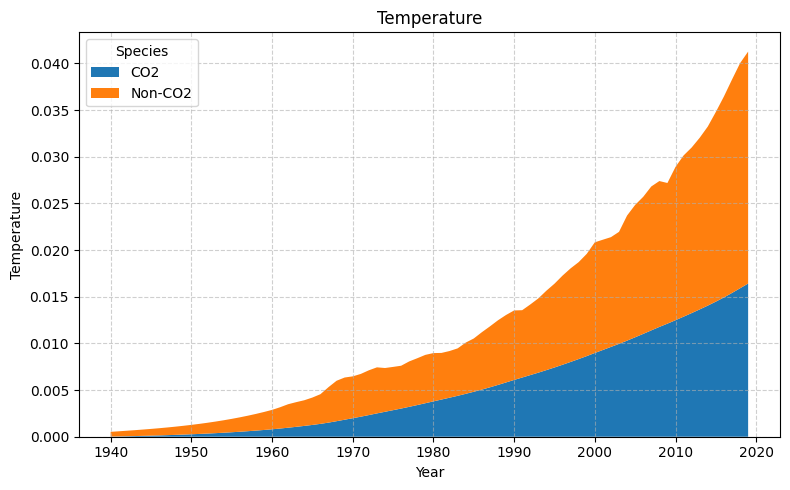

In [6]:
# --- Plot results ---
plot_simulation_results(results, data_var="temperature", species=["CO2", "Non-CO2"], stacked=True)